In [1]:
import pandas as pd
import numpy as np
import numpy as hsplit
import matplotlib.pyplot as plt
from sympy import *

def dataSet(dirExcel,numCol): # "numCol" = número de columnas a agrupar (debe ser divisor exacto de las col de la matriz)
   df = pd.read_excel(dirExcel, header=None) # leyendo hoja de Excel
   matriz = df.to_numpy() # obteniendo matriz afín a numpy
   F,C = matriz.shape # obteniendo número de filas y columnas de la matriz
   delta = int(C/numCol) # determinando número de submatrices
   vProm = np.ones((numCol,1))*(1/numCol) # vector promediador de dimensión "numCol"
   data = np.empty((F,0), int) # vector columna vacio de "F" filas
   d = np.hsplit(matriz,delta) # arreglo de submatrices de "delta" columnas a partir de "matriz"
   for k in range(len(d)):
       w = np.dot(d[k],vProm) # producto punto entre la primera submatriz y "unos"
       data = np.append(data, w, axis=1) # adicionando resultado anterior (columna) a data
   return (data)

data = dataSet("kaggleData.xlsx",8)

[[ 59.375  34.875  26.875 ...  51.     65.25   52.25 ]
 [ 33.375  28.75   33.25  ...  96.    121.375 101.5  ]
 [ 82.5    72.75   72.    ... 107.125 123.125  88.125]
 ...
 [ 89.375  70.     61.25  ... 136.375 120.875  79.25 ]
 [ 46.625  42.     32.75  ...  64.     81.125  66.5  ]
 [ 42.125  32.     29.625 ...  49.5    70.625  71.5  ]]
397 12
0
1
2
3
4
5
6
7
8
9
10
11


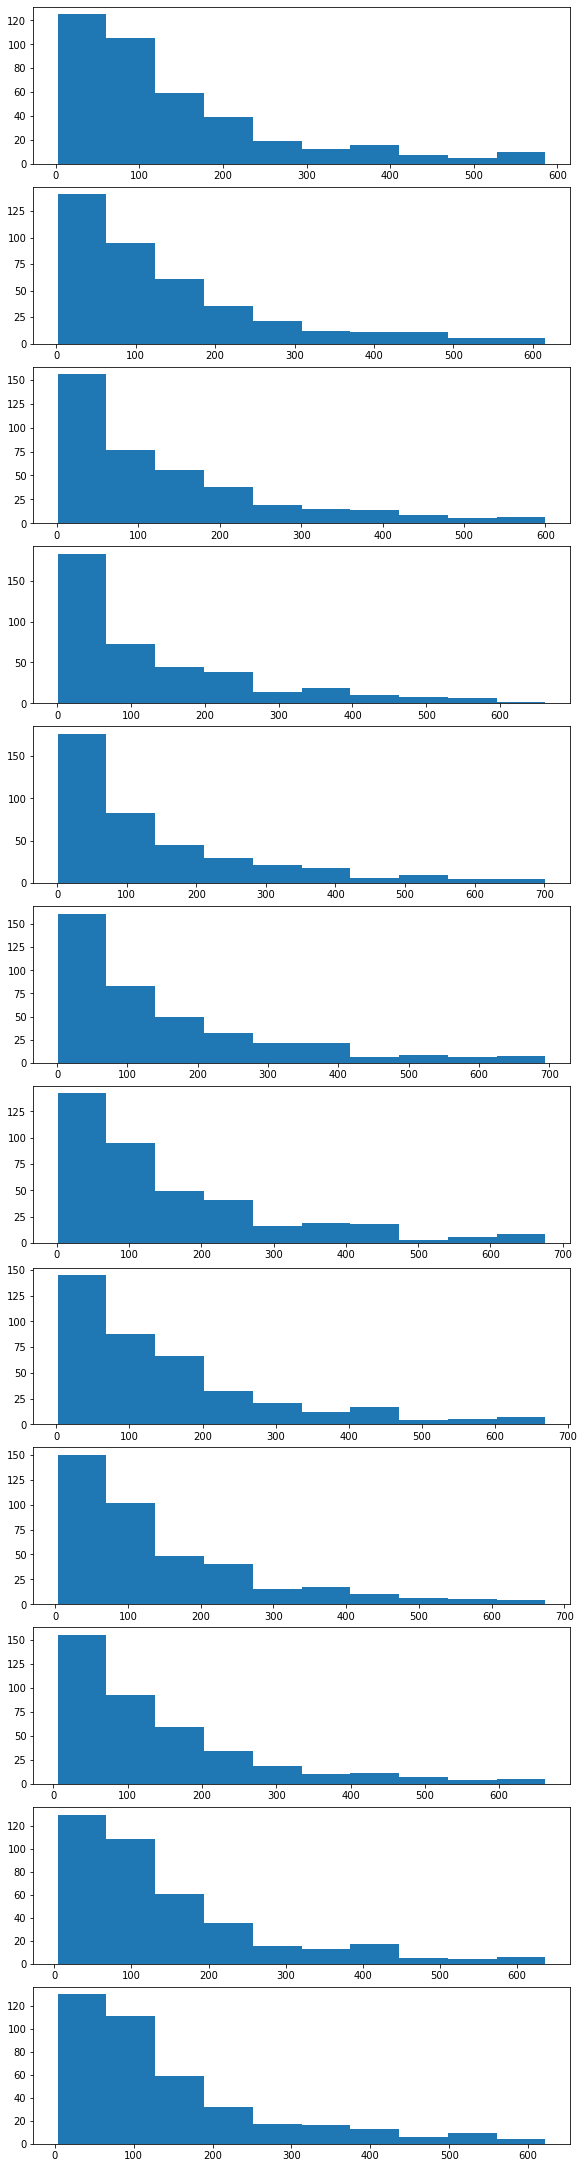

In [2]:
print(data)
filas,columnas = data.shape
print(filas,columnas)
fig,axs=plt.subplots(columnas,1,figsize=(8,30),layout="constrained")

data=data.transpose()

for i,el in enumerate(data):
    print(i)
    axs[i].hist(el)
    # if i is 2:
    #     break

## Robust Energy Management System

El objetivo de este problema de optimización es minimizar todos los costos de operación en una red electrica mientras esta sujeta a restricciones de generación y de transmisión.

\begin{equation}
\min_{{{P}_{g}},{{P}_{dn}},{{P}_{R}}} \sum_{t=1}^{T}(\sum_{m=1}^{M} {C}_{m}^{t}({P}_{Gm}^{t})-\sum_{n=1}^{N} {U}_{Dn}^{t}({P}_{Dn}^{t}))+ G(\{{P}_{R}^{t} \})
\end{equation}

Sujeto a las siguientes restricciones:

${{P}_{Gm}^{min}}\leq {{P}_{Gm}^{t}} \leq {{P}_{Gm}^{max}}$\\

$\sum_{m=1}^{M} ({P}_{Gm}^{max}-{P}_{Gm}^{t}) \geq SR^{t}$

${{P}_{Dn}^{min}}\leq {{P}_{Dn}^{t}} \leq {{P}_{Dn}^{max}}$\\

${{P}_{R}^{min}}\leq {{P}_{R}^{t}} \leq {{P}_{R}^{max}}$\\

$\sum_{m=1}^{M} {P}_{Gm}^{t}+{P}_{R}^{t}={L}^{t}+\sum_{mn1}^{N}{P}_{Dn}^{t}$

Donde:

${C}_{m}^{t}({P}_{Gm}^{t})={a}_{m}(({P}_{Gm}^{t})^2)+{b}_{m}({P}_{Gm}^{t})$\\

${U}_{Dn}^{t}({P}_{Dn}^{t})={c}_{n}(({P}_{Gm}^{t})^2)+{d}_{n}({P}_{Gm}^{t})$\\

$G(\{{P}_{R}^{t} \})=\frac{{\alpha}^{t}-{\beta}^{t}}{2}|{P}_{R}^{t}-{W}_{i}^{t}|+\frac{{\alpha}^{t}+{\beta}^{t}}{2}({P}_{R}^{t}-{W}_{i}^{t})$

In [29]:
import pandas as pd
import numpy as np
import numpy as hsplit
import matplotlib.pyplot as plt
from sympy import *

Gm_df=pd.read_excel('Data_0.xlsx',sheet_name='Gm') #Info generadores convencionales
Pd_df=pd.read_excel('Data_0.xlsx',sheet_name='Pd')  #Info Carga estatica
Lt_df=pd.read_excel('Data_0.xlsx',sheet_name='Lt') #Info Transacciones de energía
Wi_df=pd.read_excel('Data_0.xlsx',sheet_name='Wi') #Info generadores FCNER
Bj_df=pd.read_excel('Data_0.xlsx',sheet_name='Bj') #Info Baterias

#I'm using 1h periods
deltaT=1

#Se crean las variables a partir de la información de los datasets

#Info de generadores convencionales
Gm_min=np.array(Gm_df['Pg_min'].values)[:,np.newaxis]
Gm_max=np.array(Gm_df['Pg_max'].values)[:,np.newaxis]
am=np.array(Gm_df['a_m'].values)[:,np.newaxis]
bm=np.array(Gm_df['b_m'].values)[:,np.newaxis]

#make em vectors inside xls
Rdown_m=np.array(Gm_df['Rup'].values)[:,np.newaxis]
Rup_m=np.array(Gm_df['Rdown'].values)[:,np.newaxis]
SR_t=10 

#Info de Carga estatica
Pd_min=np.array(Pd_df['Pd_min'].values)[:,np.newaxis]
Pd_max=np.array(Pd_df['Pd_max'].values)[:,np.newaxis]
cn=np.array(Pd_df['c_n'].values)[:,np.newaxis]
dn=np.array(Pd_df['d_n'].values)[:,np.newaxis]

#Info Horizonte Intercambio
Pr_min=1
Pr_max=40

#info de Balance de potencia

Lt=np.array(Lt_df['Lt'].values)
alpha=np.array(Lt_df['alpha'].values)
betha=np.array(Lt_df['beta'].values)

Al = np.array([(alpha[i]-betha[i])/2 for i in range(len(alpha))] )
Bl=  np.array([(alpha[i]+betha[i])/2 for i in range(len(alpha))] ) 

#Info de generadores eolicos
w1=np.array(Wi_df['w_1'].values)
w2=np.array(Wi_df['w_2'].values)

#Info Baterias
PBmin=np.array(Bj_df['Pmin'].values)[:,np.newaxis]
PBmax=np.array(Bj_df['Pmax'].values)[:,np.newaxis]
Bmin=np.array(Bj_df['Bmin'].values)[:,np.newaxis]
Bmax=np.array(Bj_df['Bmax'].values)[:,np.newaxis]
BatEfcy=np.array(Bj_df['efficiency'].values)

#Se declara variable T, en representación al tiempo, M generadores, N cargas, J baterias
T=len(Lt)
M=len(am)
N=len(cn)
J=len(Bmin)

A_m=np.zeros((len(am),len(am)))
for i in range(len(am)): A_m[i,i]=am[i] 
C_n=np.zeros((len(cn),len(cn)))
for i in range(len(cn)): C_n[i,i]=cn[i]

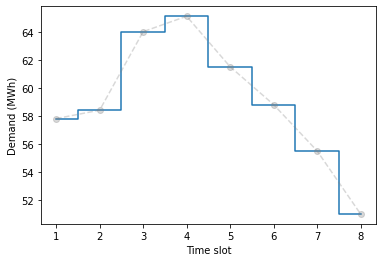

In [3]:
# Se grafica la carga a utilizar a lo largo de los T periodos de tiempo.
plt.plot(Lt_df.index+1, Lt_df['Lt'],drawstyle='steps-mid') 
plt.plot(Lt_df.index+1, Lt_df['Lt'], 'o--', color='grey', alpha=0.3)
plt.xlabel('Time slot')
plt.ylabel('Demand (MWh)')
plt.show()

Ya con los datos cargados previamente, se procede a crear el modelo mediante la libreria RSOME de Python, la cual desarrolla problemas mediante la implementación de la teoría de la Optimización Robusta(RO), y la Robustamente Distribucional(DRO).

In [30]:
from rsome import ro #Se importa la librería de Optimización Robusta
from rsome import eco_solver as eco #Se selecciona la interfaz ecos para solucionar problemas de optimization
from rsome import msk_solver as msk #Se selecciona la interfaz mosek  para solucionar problemas de optimization
import rsome as rso

from rsome import dro
from rsome import norm
from rsome import E

# se crea modelo en RSOME

model=ro.Model('NMGs') #Modelo llamado NMGs

print(f'M={M}, N={N}, J={J}, T={T}')
#se crean las variables de decisión Pgm
Pgm=model.dvar(shape=(M,T),name='Pgm') #Se define variable de decisión Pgm de la forma [3x8]
Pdn=model.dvar(shape=(N,T),name='Pdn')#Se define variable de decisión Pdn de la forma [6x8]
Pr=model.dvar(shape=(T),name='Pr')#Se define variable de decisión Pr de la forma [8]
PBj=model.dvar(shape=(J,T),name='PBj')#Se define variable de decisión Pdn de la forma [5x8]
Bj=model.dvar(shape=(J,T),name='Bj')#Se define variable de decisión Pdn de la forma [5x8]

M=3, N=6, J=5, T=24


Se crea un modelo de minimización acorde  con la inofrmación suministrada en: https://xiongpengnus.github.io/rsome/example_ucp sobre como se puede modelar un problema de doble sumatoría:

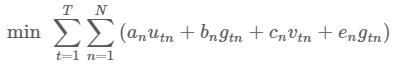

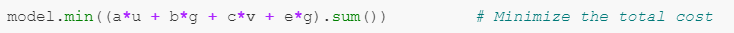

Asi como de la suministrada en https://xiongpengnus.github.io/rsome/example_opf:

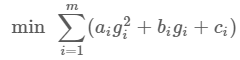

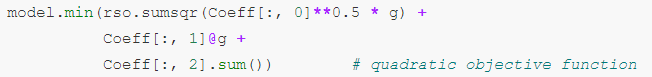

In [18]:
(am**0.5*Pgm)
Bj[:,-1]>=Bmin#.reshape(-1)
-cn

array([[0.002 ],
       [0.0017],
       [0.003 ],
       [0.0024],
       [0.0015],
       [0.0037]])

In [31]:
#cm=212.3076
#Pgm_=am**0.5*Pgm
#Ctm=rso.sumsqr(Pgm_.reshape(-1))+(bm*Pgm).sum()+cm*M*T
Ctm=(bm*Pgm).sum()
print(Ctm)

Pdn_=(-cn)**0.5*Pdn
Udn=-rso.sumsqr(Pdn_.reshape(-1))+(dn*Pdn).sum()
#Udn=(dn*Pdn).sum()
print(Udn)

Fcost=Ctm-Udn
print(Fcost)

model.min(Fcost)

an affine expression
a sum of squares expression
a sum of squares expression


In [168]:
##### COST OPTIMIZATION FUNCTION TESTING

rso.quad(Pgm[:,0],A_m)+bm@Pgm
rso.quad(Pdn[:,0],C_n)+dn@Pdn
#Pgm Pdn Pr
#Sm(C_m(P_Gm))
#am*rso.square(Pgm)


#Esta linea de codigo lo que realiza es una multiplica
#din=(am**0.5@Pgm)

8 sum of squares expressions

Se procede a crear las diferentes funciones de restricción relacionadas al modelo anterior. de la forma y como se muestra en el problema de Unit Commitment

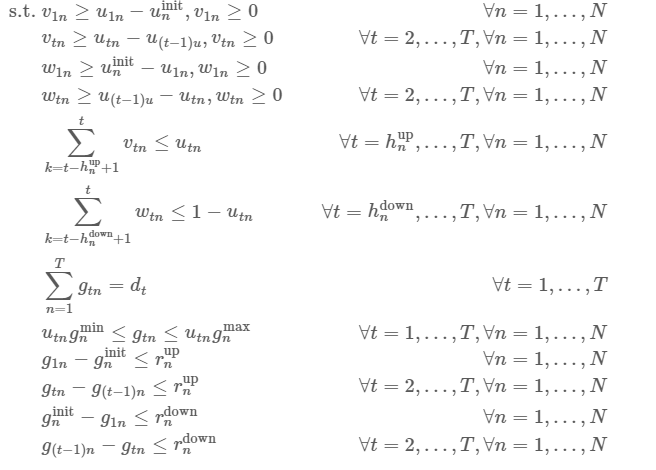

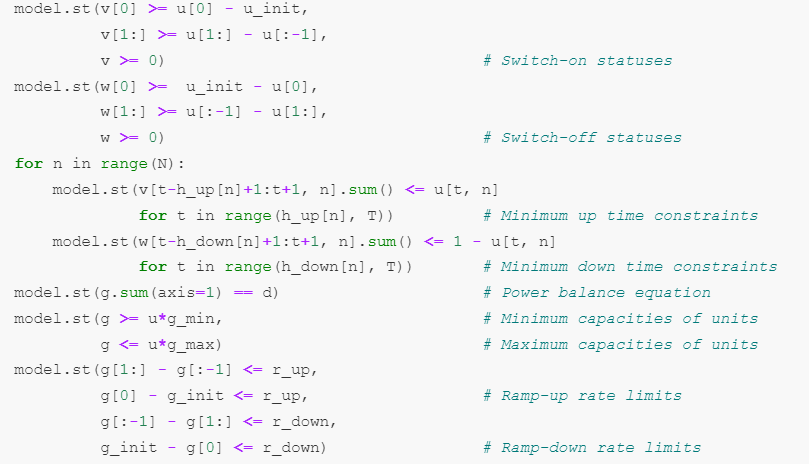

O en el caso de PowerFlowDC, tambien se puede analizar de la siguiente manera:

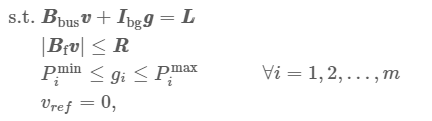

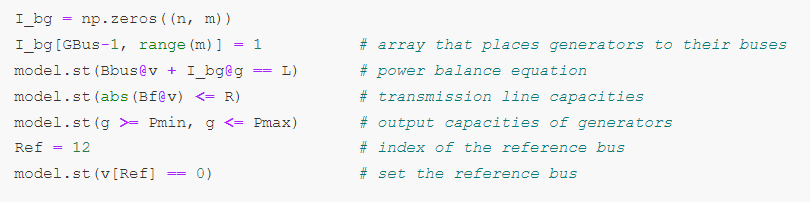


In [32]:
#### BASIC BALANCE RESTRICTIONS

for gen in Pgm: #Bands Pgm
    model.st(Gm_min >= gen,gen<=Gm_max)
    print("pgm_b",end=",")
print("")

for load in Pdn: #Bands Pdn
    model.st(Pd_min >= load,load<=Pd_max)
    print("pdn_b",end=",")
print("")

#Bands for grid interface Pr
model.st(Pr_min >=Pr,Pr<=Pr_max)
print("pr_b")

for gen in Pgm: #Spinng Resrv
    model.st((Gm_max-gen).sum()>=SR_t)

for idx,period in enumerate(Pgm.T): #Ramp Up/Down
    if (idx==0): continue
    print(f'{idx}-{period}',end=",")
    print(Pgm[:,idx]==period)
    model.st(-Rdown_m<=Pgm[:,idx]-Pgm[:,idx-1]<=Rup_m)
print("")

for t in range(T): #Power Balance
    model.st(sum(Pgm[:,t])+Pr[t]==sum(PBj[:,t])+Lt[t]+Pdn[:,t].sum())

#### Battery Restrictions

for col in PBj: #PBj Bands
    model.st(PBmin<=col,col<=PBmax)
    print("PBj_b",end=",")
print("")

for col in PBj: #Bj bands
    model.st(0<=col,col<=Bmax)
    print("Bj_b",end=",")
print("")

#End Period Status is min bounded
model.st(Bj[:,-1]>=Bmin)
#i could also Bj[:,-1]==Bj[:,0] to guarantee repeating cycle

for idx,row in enumerate(Bj.T): #Battery (dis)charging action
    if (idx==0): continue
    print(f'{idx}, {row}',end="")
    model.st(Bj[:,idx]==Bj[:,idx-1]+PBj[:,idx]*deltaT)
print("")

for idx,period in enumerate(Bj.T):#Battery max discharge available
    if (idx==0): continue
    model.st(-BatEfcy*Bj[:,idx-1]<=PBj[:,idx]*deltaT)

pgm_b,pgm_b,pgm_b,
pdn_b,pdn_b,pdn_b,pdn_b,pdn_b,pdn_b,
pr_b
1-3 affine expressions,3 linear constraints
2-3 affine expressions,3 linear constraints
3-3 affine expressions,3 linear constraints
4-3 affine expressions,3 linear constraints
5-3 affine expressions,3 linear constraints
6-3 affine expressions,3 linear constraints
7-3 affine expressions,3 linear constraints
8-3 affine expressions,3 linear constraints
9-3 affine expressions,3 linear constraints
10-3 affine expressions,3 linear constraints
11-3 affine expressions,3 linear constraints
12-3 affine expressions,3 linear constraints
13-3 affine expressions,3 linear constraints
14-3 affine expressions,3 linear constraints
15-3 affine expressions,3 linear constraints
16-3 affine expressions,3 linear constraints
17-3 affine expressions,3 linear constraints
18-3 affine expressions,3 linear constraints
19-3 affine expressions,3 linear constraints
20-3 affine expressions,3 linear constraints
21-3 affine expressions,3 linear constraints
22-

In [ ]:
##### DRO scenario stuff
I=2                                         # 2 Wind Uncertainty Sources
S=len(data[0])                              # No. of Scenarios
model = dro.Model(S)                        # create a DRO model with S scenarios
w = model.rvar(I)                           # random available wind power w
u = model.rvar()                            # auxiliary random variable

Pgm[:,1]
w_top=np.array([1000]*I)      #Con base en los histogramas de allá arriba dije que los límites son 1000 en cada generador_i
w_top

##### DRO support set construction

w_top=[]
theta = 40        #Pablo thing


fset = model.ambiguity()                                        # create an ambiguity set
for s in range(S):                                              # still have to get the rest of the constraints for W here i believe
    fset[s].suppset(0 <= w, w <= w_top,norm(w - w_top[s]) <= u)  # define the support for each scenario
fset.exptset(E(u) <= theta)                                     # the Wasserstein metric constraint
pr = model.p                                                    # an array of scenario probabilities
fset.probset(pr == 1/S)                                         # support of scenario probabilities

# los problemas están en la definicion del support set, pero es raro
# porque está exactamente igual a https://xiongpengnus.github.io/rsome/example_dro_nv#ref1
# creo yo

In [33]:
#Se resuelve el modelo, mediante la linea de codigo:
primal = model.solve(msk)
print(Pgm.get())
print(Pdn.get())
Pr.get()

Being solved by Mosek...


Solution status: optimal
Running time: 0.0216s
[[-378.6051042  -379.68685423 -380.90843329 -381.94335469 -381.19223478
  -379.31267377 -377.90278278 -376.49273301 -373.45288851 -369.96196265
  -366.71999774 -364.37048538 -362.20909534 -360.42369528 -359.76580405
  -360.00043538 -359.3998299  -353.80301305 -352.70350395 -356.30273683
  -359.00341063 -362.3038903  -366.80317265 -368.50310841]
 [   7.9999995     7.99999951    7.99999951    7.9999995     7.99999951
     7.99999951    7.99999951    7.99999952    7.99999951    7.99999951
     7.99999951    7.99999951    7.99999951    7.99999951    7.99999951
     7.99999951    7.99999951    7.9999995     7.9999995     7.9999995
     7.9999995     7.99999951    7.99999953    7.99999951]
 [  14.99999934   14.99999937   14.99999935   14.99999935   14.99999935
    14.99999936   14.99999936   14.99999937   14.99999937   14.99999936
    14.99999936   14.99999936   14.99999936   14.99999936   14.99999936
    14.99999936   14.99999935   14.99999935 

array([0.99999985, 0.99999984, 0.99999983, 0.99999983, 0.99999983,
       0.99999983, 0.99999983, 0.99999982, 0.99999982, 0.99999982,
       0.99999982, 0.99999983, 0.99999983, 0.99999983, 0.99999983,
       0.99999983, 0.99999983, 0.99999983, 0.99999983, 0.99999983,
       0.99999982, 0.99999982, 0.99999981, 0.9999998 ])

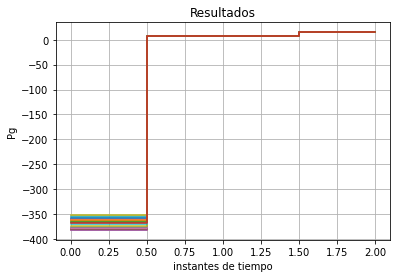

In [40]:
sol=Pgm.get()
pdsol=pd.DataFrame(sol)
pdsol

plt.figure()
plt.plot(pdsol.index[:50], pdsol.values[:50],drawstyle='steps-mid')
plt.xlabel('instantes de tiempo')
plt.ylabel('Pg')
#plt.legend(pdsol.columns)
plt.title('Resultados')
plt.grid(True)
#plt.xlim(0, 49)
plt.show()

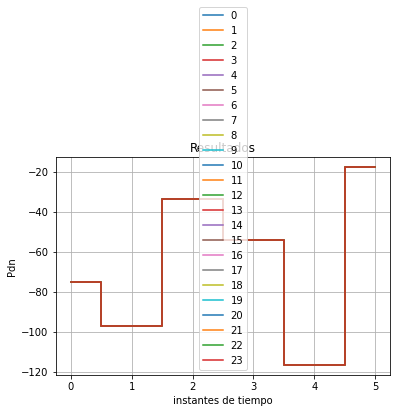

In [39]:
sol=Pdn.get()
pdsol=pd.DataFrame(sol)
pdsol

plt.figure()
plt.plot(pdsol.index[:50], pdsol.values[:50],drawstyle='steps-mid')
plt.xlabel('instantes de tiempo')
plt.ylabel('Pdn')
plt.legend(pdsol.columns)
plt.title('Resultados')
plt.grid(True)
#plt.xlim(0, 49)
plt.show()

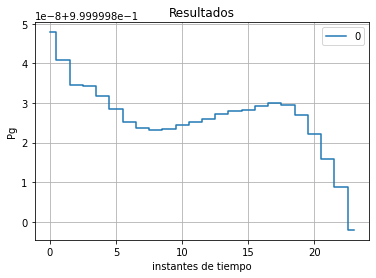

In [36]:
sol=Pr.get()
pdsol=pd.DataFrame(sol)
pdsol

plt.figure()
plt.plot(pdsol.index[:50], pdsol.values[:50],drawstyle='steps-mid')
plt.xlabel('instantes de tiempo')
plt.ylabel('Pr')
plt.legend(pdsol.columns)
plt.title('Resultados')
plt.grid(True)
#plt.xlim(0, 49)
plt.show()

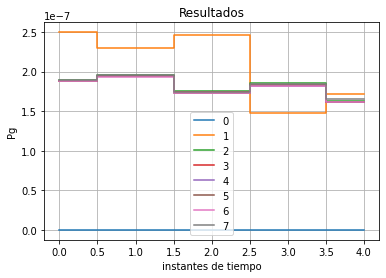

In [27]:
sol=PBj.get()
pdsol=pd.DataFrame(sol)
pdsol

plt.figure()
plt.plot(pdsol.index[:50], pdsol.values[:50],drawstyle='steps-mid')
plt.xlabel('instantes de tiempo')
plt.ylabel('Pg')
plt.legend(pdsol.columns)
plt.title('Resultados')
plt.grid(True)
#plt.xlim(0, 49)
plt.show()

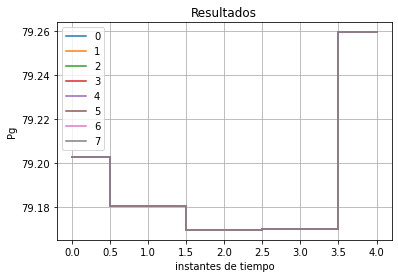

In [28]:
sol=Bj.get()
pdsol=pd.DataFrame(sol)
pdsol

plt.figure()
plt.plot(pdsol.index[:50], pdsol.values[:50],drawstyle='steps-mid')
plt.xlabel('instantes de tiempo')
plt.ylabel('Pg')
plt.legend(pdsol.columns)
plt.title('Resultados')
plt.grid(True)
#plt.xlim(0, 49)
plt.show()